# Advanced Furnace ML：小数据预测与安全推荐

本实验使用前248炉开发、最后44炉锁定审计。开发区采用三个大时间折：**148/33、181/33、214/34**。模型与推荐规则冻结后才读取最后44炉。

推荐只有在保守预测低于相似历史实际气耗、至少2/3时间折同意、历史可行、不贴边且位于±10%信任区域时才通过。**离线预计节省不等于工厂实际节省，必须经过现场受控试验。**

In [1]:
from pathlib import Path
import sys
import warnings

import joblib
import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import display

warnings.filterwarnings('ignore')
cwd = Path.cwd().resolve()
PROJECT_ROOT = cwd.parent if cwd.name == 'notebooks' else (cwd / 'advanced_furnace_ml' if (cwd / 'advanced_furnace_ml').exists() else cwd)
WORKSPACE_ROOT = PROJECT_ROOT.parent
sys.path.insert(0, str(PROJECT_ROOT / 'src'))

from advanced_furnace_ml.artifacts import load_bundle, predict_bundle
from advanced_furnace_ml.data import FEATURE_COLS, load_batch_data
from advanced_furnace_ml.pipeline import run_advanced_pipeline

EXCEL_PATH = WORKSPACE_ROOT / '4_month_data_2026_02_01_2026_06_25.xlsx'
result = run_advanced_pipeline(
    EXCEL_PATH, PROJECT_ROOT, optimizer_budget=600, seeds=[0, 1, 2]
)
print('Project:', PROJECT_ROOT)
print('Selected before lock:', result['selected_before_lock'])
print('Locked batches:', len(result['locked_audit']))

Project: /Users/tian/Desktop/prediction_project/advanced_furnace_ml
Selected before lock: OOFEnsemble
Locked batches: 19


## 1. 开发区模型矩阵与三时间折表现

,candidate,route,mae_mean,rmse_mean,rmse_std,rmse_worst,wape_mean,r2_mean,error_gt_10pct_rate,selection_score,conformal_radius_90
0,OOFEnsemble,mixed_total,295.8505,384.5394,118.2728,460.2973,0.0828,0.7742,0.3113,414.1076,531.1714
1,ElasticNet__direct,direct,300.5711,388.3532,119.8729,487.9079,0.0842,0.7547,0.3113,418.3214,559.3290
2,Ridge__direct,direct,304.6496,397.5958,124.0488,485.8076,0.0853,0.7530,0.3116,428.6080,561.3256
3,Ridge+LGBMResidual__direct,direct,300.8135,398.0474,139.4750,509.7700,0.0842,0.7423,0.3113,432.9161,598.7751
4,GPR__direct,direct,295.4180,419.5917,150.8478,577.8289,0.0824,0.7814,0.3408,457.3037,544.6171
5,Huber+LGBMResidual__direct,direct,299.9307,414.6534,199.2812,615.8980,0.0839,0.6681,0.3116,464.4737,595.4712
6,Huber__direct,direct,301.4335,417.8556,197.3896,613.3270,0.0843,0.6689,0.3015,467.2030,527.0140
7,ElasticNet__unit,unit,335.6620,452.7726,117.1311,563.7786,0.0945,0.6573,0.3607,482.0554,598.3371
8,Ridge+LGBMResidual__unit,unit,324.8165,450.6692,146.2683,577.9723,0.0910,0.6632,0.3809,487.2363,590.1017
9,Ridge__unit,unit,338.2359,464.4812,123.3833,567.5879,0.0951,0.6517,0.3506,495.3270,595.8458


LightGBM / CatBoost small-data parameter variants


,model,variant,selection_score,rmse_mean,rmse_std,selected
0,LightGBM,very_small,964.6986,850.3139,457.5387,True
1,LightGBM,small,990.1853,885.0496,420.5427,False
2,LightGBM,medium_small,988.3384,893.9475,377.5637,False
3,CatBoost,depth3,969.9926,857.3949,450.3905,False
4,CatBoost,depth4,916.8438,808.0693,435.0981,True


Repeated random CV reference only (not used to select the chronological Champion)


,candidate,random_rmse
10,Huber__direct,618.2668
8,Huber+LGBMResidual__direct,637.4605
16,Ridge+LGBMResidual__unit,646.2385
2,ElasticNet__direct,653.1885
17,Ridge__direct,656.2188
18,Ridge__unit,662.8882
15,Ridge+LGBMResidual__direct,667.5028
3,ElasticNet__unit,672.7316
11,Huber__unit,676.8081
9,Huber+LGBMResidual__unit,683.3440


,candidate,route,fold,train_size,valid_size,mae,rmse,wape,r2,error_gt_10pct_rate
48,Huber+LGBMResidual__direct,direct,0,148,33,347.0590,410.6670,0.0903,0.9411,0.5152
12,Huber__direct,direct,0,148,33,353.6063,421.6377,0.0920,0.9379,0.4545
6,ElasticNet__direct,direct,0,148,33,350.9690,421.8593,0.0913,0.9379,0.4242
51,Huber+LGBMResidual__unit,unit,0,148,33,377.5077,438.7766,0.0982,0.9328,0.4848
42,Ridge+LGBMResidual__direct,direct,0,148,33,361.8537,442.6440,0.0941,0.9316,0.4545
54,OOFEnsemble,mixed_total,0,148,33,353.4111,445.0678,0.0919,0.9308,0.4242
0,Ridge__direct,direct,0,148,33,362.8203,451.2248,0.0944,0.9289,0.4545
15,Huber__unit,unit,0,148,33,378.1396,452.2853,0.0984,0.9286,0.4545
9,ElasticNet__unit,unit,0,148,33,366.6740,464.1871,0.0954,0.9248,0.4848
45,Ridge+LGBMResidual__unit,unit,0,148,33,381.8279,483.1418,0.0993,0.9185,0.5152


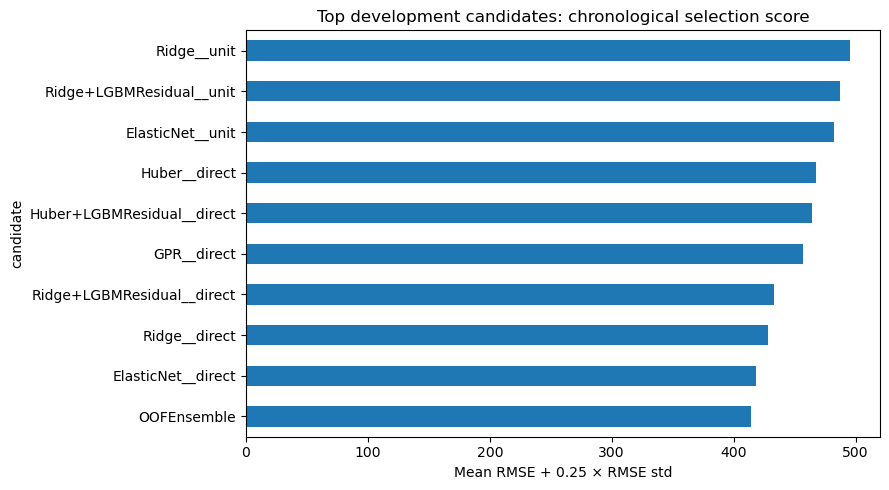

In [2]:
model_cv_summary = result['model_summary'].copy()
fold_metrics = pd.read_csv(PROJECT_ROOT / 'reports/chronological_fold_metrics.csv')
tree_tuning_summary = result['tree_tuning_summary'].copy()
random_cv_reference = result['random_cv_reference'].copy()
display(model_cv_summary.round(4))
print('LightGBM / CatBoost small-data parameter variants')
display(tree_tuning_summary.round(4))
print('Repeated random CV reference only (not used to select the chronological Champion)')
display(random_cv_reference.groupby('candidate', as_index=False).agg(random_rmse=('rmse', 'mean')).sort_values('random_rmse').round(4))
display(fold_metrics.sort_values(['fold', 'rmse']).round(4))
ax = model_cv_summary.head(10).sort_values('selection_score').plot.barh(
    x='candidate', y='selection_score', figsize=(9, 5), legend=False,
    title='Top development candidates: chronological selection score'
)
ax.set_xlabel('Mean RMSE + 0.25 × RMSE std')
plt.tight_layout()
plt.show()

## 2. 最后44炉锁定审计

下表只用于冻结后的最终审计，不反向修改开发区选择。

In [3]:
locked_audit = result['locked_audit'].copy()
display(locked_audit.round(4))
selected_lock = locked_audit.loc[locked_audit['selected_before_lock']].iloc[0]
print(f"Frozen Champion locked RMSE: {selected_lock['rmse']:.2f}")
print(f"Frozen Champion 90% interval coverage: {selected_lock['interval_coverage_90']:.1%}")

,candidate,route,mae,rmse,wape,r2,error_gt_10pct_rate,rmse_bootstrap_low95,rmse_bootstrap_high95,interval_coverage_90,interval_mean_width,native_model_std_mean,selected_before_lock
0,GPR__unit,unit,287.8124,366.3043,0.0868,0.7905,0.3636,288.5380,439.8998,0.8864,1153.1740,319.0182,False
1,GPR__direct,direct,286.1675,366.8873,0.0863,0.7899,0.3636,297.7524,438.6477,0.8636,1089.2342,322.3759,False
2,Huber+LGBMResidual__direct,direct,301.8680,394.2801,0.0911,0.7573,0.3636,307.7646,469.8616,0.8409,1190.9423,NaN,False
3,Huber__direct,direct,316.7977,397.0146,0.0956,0.7539,0.3636,317.3289,472.2936,0.7955,1054.0281,NaN,False
4,OOFEnsemble,mixed_total,313.6401,398.3037,0.0946,0.7523,0.4091,321.9028,466.2300,0.7727,1062.3427,NaN,True
5,Ridge+LGBMResidual__unit,unit,322.6355,405.8321,0.0973,0.7429,0.4091,318.0237,492.2528,0.8409,1180.2033,NaN,False
6,Ridge+LGBMResidual__direct,direct,311.9596,410.7470,0.0941,0.7366,0.4091,324.9253,486.8757,0.7955,1197.5501,NaN,False
7,ElasticNet__direct,direct,328.8302,414.9558,0.0992,0.7312,0.4091,328.4351,493.3495,0.8182,1118.6581,NaN,False
8,Ridge__direct,direct,328.9863,415.1701,0.0992,0.7309,0.4091,328.7156,493.4611,0.8182,1122.6511,NaN,False
9,Huber__unit,unit,342.3278,421.0456,0.1033,0.7233,0.4318,346.4937,497.7103,0.8182,1171.4205,NaN,False


Frozen Champion locked RMSE: 398.30
Frozen Champion 90% interval coverage: 77.3%


## 3. 推荐模型、三个优化器与安全门

In [4]:
recommendation_summary = result['recommendation_summary'].copy()
optimizer_runs = result['optimizer_runs'].copy()
optimizer_summary = optimizer_runs.groupby(['candidate', 'optimizer'], as_index=False).agg(
    median_best_objective=('best_objective', 'median'),
    mean_safe_candidate_rate=('safe_candidate_rate', 'mean'),
    evaluations=('evaluations', 'first'),
)
display(optimizer_summary.round(4))
display(recommendation_summary.round(4))
production = result['production_recommendation']
print('Production trial candidate / fallback:')
display(pd.DataFrame([production]))
print(result['bundle']['offline_savings_disclaimer'])

,candidate,optimizer,median_best_objective,mean_safe_candidate_rate,evaluations
0,GPR__direct,bayesian_optimization,3450.5690,0.4239,600
1,GPR__direct,genetic_algorithm,3453.1960,0.7483,600
2,GPR__direct,random_search,3454.8936,0.2878,600
3,Huber+LGBMResidual__direct,bayesian_optimization,3424.0983,0.3728,600
4,Huber+LGBMResidual__direct,genetic_algorithm,3466.1470,0.6678,600
5,Huber+LGBMResidual__direct,random_search,3445.7542,0.1250,600
6,LightGBM__direct,bayesian_optimization,3287.7419,0.4406,600
7,LightGBM__direct,genetic_algorithm,3287.5151,0.7622,600
8,LightGBM__direct,random_search,3288.7371,0.2878,600
9,OOFEnsemble,bayesian_optimization,3450.6023,0.4161,600


,candidate,optimizer,source,safety_pass,safety_grade,actual_baseline_gas,conservative_predicted_gas,estimated_saving_vs_actual_baseline,fold_consensus_rate,prediction_std,safety_reasons,10#熔炼炉固体料重量比例,熔炼炉B当前批次等待时长_PLC,熔炼炉B当前批次炉门打开次数_PLC,熔炼炉B当前批次炉门打开时长_PLC
0,LightGBM__direct,genetic_algorithm,model_optimization,True,A,3701.28,3293.6657,407.6143,1.0,72.6579,,38.0952,0.6498,14.0,69.4117
1,GPR__direct,bayesian_optimization,model_optimization,True,A,3701.28,3443.7081,257.5719,1.0,10.0637,,36.2272,0.5888,14.0,68.0715
2,Ridge+LGBMResidual__direct,bayesian_optimization,model_optimization,True,A,3701.28,3477.1237,224.1563,1.0,11.2628,,36.4773,0.5946,14.0,70.2157
3,Huber+LGBMResidual__direct,bayesian_optimization,model_optimization,True,A,3701.28,3431.1327,270.1473,1.0,70.6126,,36.4684,0.5890,14.0,63.5447
4,OOFEnsemble,genetic_algorithm,model_optimization,True,A,3701.28,3438.1875,263.0925,1.0,10.2433,,36.3846,0.6061,14.0,63.4733


Production trial candidate / fallback:


,source,recommendation,conservative_predicted_gas,estimated_saving_vs_actual_baseline,actual_baseline_gas,historical_low_gas_median,fold_consensus_rate,prediction_std,normalized_knn_distance,safety_pass,safety_grade,safety_reasons,candidate,optimizer
0,model_optimization,"{'10#熔炼炉固体料重量比例': 38.095199605793454, '熔炼炉B当前批...",3293.66565,407.61435,3701.28,2876.395,1.0,72.657944,0.249659,True,A,[],LightGBM__direct,genetic_algorithm


离线预计节省不等于工厂实际节省，必须经过现场受控试验。


## 4. Joblib重载验证与最终结论

In [5]:
bundle_path = PROJECT_ROOT / 'artifacts/advanced_furnace_bundle.joblib'
bundle = load_bundle(bundle_path)
df = load_batch_data(EXCEL_PATH)
smoke = predict_bundle(bundle, df[FEATURE_COLS].iloc[[0]])
display(smoke.round(4))
print('Prediction Champion:', bundle['selected_model_name'])
print('Recommendation model:', bundle['recommendation_model_name'])
print('Recommendation safety pass:', bundle['production_recommendation_86000']['safety_pass'])
print('offline_savings_disclaimer:', bundle['offline_savings_disclaimer'])
print('离线预计节省不等于工厂实际节省；实际效果必须通过现场受控试验。')

,predicted_gas,prediction_lower_90,prediction_upper_90,chronological_fold_std,model_name
0,4756.6632,4225.4918,5287.8346,16.5365,OOFEnsemble


Prediction Champion: OOFEnsemble
Recommendation model: LightGBM__direct
Recommendation safety pass: True
offline_savings_disclaimer: 离线预计节省不等于工厂实际节省，必须经过现场受控试验。
离线预计节省不等于工厂实际节省；实际效果必须通过现场受控试验。
